# Exact quantum dynamics with the new (PyTorch) TD-SE (SOFT) solver: Multiple nuclear degrees of freedom (nonadiabatic dynamics)

## Table of Content <a name="TOC"></a>

1. [Model Hamiltonians](#1)
2. [Setup and run calculations](#2)
3. [Ploting the results](#3)

    3.1. [Plotting the density matrix (in r-space) profiles of 2D system](#3.1)
    
    3.2. [Plotting the density matrix (in k-space) profiles of 2D system](#3.2)
    
    3.3. [Plotting the state-resolved density matrix (in r-space) profiles of 2D system](#3.3)
    
    3.4. [Generating animation for the density matrix (in r-space) profiles of 2D system](#3.4)

    3.5. [Generating animation for the density matrix (in k-space) profiles of 2D system](#3.5)

    3.6. [Plotting energy profiles: diabatic](#3.6)

    3.7. [Plotting energy profiles: adiabatic](#3.7)

    3.8. [Kinetic, potential, and total energy as functions of time](#3.8)

    3.9. [Adiabatic and diabatic populations as functions of time](#3.9)

### A. Learning objectives

- to define the model Hamiltonian suitable for the new TDSE solver with multiple nuclear degrees of freedom (2D in this example)
- to setup and execute a quantum dynamics calculation for 2-level 2D Hamiltonian using new exact solver written with PyTorch
- to plot the snapshots of the electronic density in the position and momentum spaces
- to save the results of the new TDSE solver calculations and using them to plot the figures


### B. Use cases

- [Define a model Hamiltonian using PyTorch](#1)
- [Numerically exact solution of the TD-SE](#2)
- [Numerically exact solution of the TD-SE using PyTorch](#2)
- [Snapshots of the dynamics in 1D](#3.1) | [also here](#3.2) | [also here](#3.3) | [also here](#3.4) 
- [Plot the PES components of multistate model Hamiltonians](#3.5) | [also here](#3.6)
- [Plotting evolution of properties from exact dynamics calculations](#3.7) | [also here](#3.8)
- [Save and load the PyTorch tensors to/from file](#3)


### C. Functions

None

### D. Classes and class members

- `libra_py`
  - `dynamics`
    - `exact_torch`
      - `compute`
        - [`exact_tdse_solver_multistate`](#4)


In [1]:
import math
import torch
import torch.fft
import numpy as np
import libra_py.dynamics.exact_torch.compute as compute
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.colors import Normalize, TwoSlopeNorm

plt.rc('axes', titlesize=24)      # fontsize of the axes title
plt.rc('axes', labelsize=24)      # fontsize of the x and y labels
plt.rc('legend', fontsize=24)     # legend fontsize
plt.rc('xtick', labelsize=24)    # fontsize of the tick labels
plt.rc('ytick', labelsize=24)    # fontsize of the tick labels

plt.rc('figure.subplot', left=0.2)
plt.rc('figure.subplot', right=0.95)
plt.rc('figure.subplot', bottom=0.13)
plt.rc('figure.subplot', top=0.88)

## 1. Model Hamiltonians
<a name="1"></a>[Back to TOC](#TOC)

Here, we set our Ferretti's model Hamiltonian, [Ferretti, A.; Granucci, G.; Lami, A.; Persico, M.; Villani, G. *J. Chem Phys.* **1996**, 104 (14), 5517–5527.] which is two-dimensional. The default coupling strength parameter, `params["gamma"]` is set to 0.01, beloning to a weak coupling region. We can investigate how the dynamics would differ according to the coupling strength, setting a range of different values [Agostini, F.; Curchod, B. F. E. *Eur. Phys. J. B* **2018**, 91 (7), 141.].

In [2]:
# Define the diabatic potential matrix for the Ferretti's model
def Ferretti_potential_matrix(Q, params):
    """
    Q: Tensor with shape [ndof, Ngrid]
    Returns diabatic potential matrix [2, 2, Ngrid]
    """
    x, y = Q[0], Q[1]  # 2D nuclear coordinate

    X1    = params.get("X1", 4.0)
    X2    = params.get("X2", 3.0)
    X3    = params.get("X3", 3.0)
    Kx    = params.get("Kx", 0.02)
    Ky    = params.get("Ky", 0.1)
    Delta = params.get("Delta", 0.01)
    alpha = params.get("alpha", 3.0)
    beta  = params.get("beta", 1.5)
    gamma = params.get("gamma", 0.01)

    # diabatic potentials
    V11 = 0.5 * Kx * (x - X1)**2 + 0.5 * Ky * y**2
    V22 = 0.5 * Kx * (x - X2)**2 + 0.5 * Ky * y**2 + Delta
    V12 = gamma * y * torch.exp(-alpha * (x - X3)**2) * torch.exp(-beta * y**2)

    Vmat = torch.empty((*x.shape, 2, 2), dtype=torch.cfloat, device=x.device)
    Vmat[..., 0, 0] = V11
    Vmat[..., 1, 1] = V22
    Vmat[..., 0, 1] = V12
    Vmat[..., 1, 0] = V12.conj()

    return Vmat

## 2. Setup and run calculations

<a name="2"></a>[Back to TOC](#TOC)

Parameters related to the nuclear distribution are set independently. Here, force constants for nuclear DOFs from the masses and position variances are transformed into angular frequency parameters for the initial nuclear wavepacket.

In [3]:
dX, dY = 0.150, 0.197
M_x, M_y = 20000,6667
a, b = 1./dX**2 , 1./dY**2
k_x, k_y = a**2 / 4 / M_x, b**2 / 4 / M_y
omega_x, omega_y = math.sqrt(k_x/M_x), math.sqrt(k_y/M_y)

print(k_x, k_y, omega_x, omega_y)

0.024691358024691357 0.024896864110960395 0.0011111111111111111 0.0019324447985645241


In [4]:
# Set up parameters
params = {
    "prefix": "Ferretti",
    "grid_size": [512, 512],       # 2D grid
    "q_min": [0.0, -2.0],
    "q_max": [10.0, 2.0],
    "save_every_n_steps": 10,
    "dt": 5.0,
    "nsteps": 410,
    "mass": [M_x, M_y],         # realistic nuclear mass unit

    "Nstates": 2,
    "representation": "adiabatic",
    "initial_state_index": 1,   # Start in adiabatic state 1
    
    "potential_fn": Ferretti_potential_matrix,
    "potential_fn_params": {
        "X1": 4.0,
        "X2": 3.0,
        "X3": 3.0,
        "Kx": 0.02,
        "Ky": 0.1,
        "Delta": 0.01,
        "alpha": 3.0,
        "beta": 1.5,
        "gamma": 0.01
    },
    "psi0_fn" : compute.gaussian_wavepacket,
    "psi0_fn_params": {
        "mass": [M_x, M_y],
        "omega": [omega_x, omega_y],
        "q0": [2.0, 0.0],            # initial position left of crossing
        "p0": [0.0, 0.0]             # initial momentum toward crossing
    },
    "method": "split-operator"
}

The solver can be prepared and executed in the following way:

In [5]:
# Instantiate solver
solver = compute.exact_tdse_solver_multistate(params)

# Initialize grids and wavefunction
solver.initialize_grids()

# Initialize operators
solver.initialize_operators()

# Run the time propagation
solver.propagate()

# Save results to file
solver.save()

print("Simulation completed and data saved.")

Initializing grids
grid_size =  tensor([512, 512])
self.ngrid =  262144
Q =  torch.Size([2, 512, 512])
dq =  tensor([0.0196, 0.0078])
K =  torch.Size([2, 512, 512])
dk =  tensor([0.6271, 1.5677])
dV =  tensor(0.0002)
dVk =  tensor(0.9831)
T.shape =  torch.Size([512, 512])
expT.shape =  torch.Size([512, 512])
V.shape =  torch.Size([512, 512, 2, 2])
expV_half.shape =  torch.Size([512, 512, 2, 2])


/home/alexvakimov/SOFTWARE/libra/_build/src/libra_py/dynamics/exact_torch/compute.py:449: UserWarning: Casting complex values to real discards the imaginary part (Triggered internally at /pytorch/aten/src/ATen/native/Copy.cpp:308.)
  self.total_energy[istep] = KE + PE


Step 0: Norm = 1.0000
Step 10: Norm = 1.0000
Step 20: Norm = 1.0000
Step 30: Norm = 1.0000
Step 40: Norm = 1.0000
Step 50: Norm = 1.0000
Step 60: Norm = 1.0000
Step 70: Norm = 1.0000
Step 80: Norm = 1.0000
Step 90: Norm = 1.0000
Step 100: Norm = 1.0000
Step 110: Norm = 1.0000
Step 120: Norm = 1.0000
Step 130: Norm = 1.0000
Step 140: Norm = 1.0000
Step 150: Norm = 1.0000
Step 160: Norm = 1.0000
Step 170: Norm = 1.0000
Step 180: Norm = 1.0000
Step 190: Norm = 1.0000
Step 200: Norm = 1.0000
Step 210: Norm = 1.0000
Step 220: Norm = 1.0000
Step 230: Norm = 1.0000
Step 240: Norm = 1.0000
Step 250: Norm = 1.0000
Step 260: Norm = 1.0000
Step 270: Norm = 1.0000
Step 280: Norm = 1.0000
Step 290: Norm = 1.0000
Step 300: Norm = 1.0000
Step 310: Norm = 1.0000
Step 320: Norm = 1.0000
Step 330: Norm = 1.0000
Step 340: Norm = 1.0000
Step 350: Norm = 1.0000
Step 360: Norm = 1.0000
Step 370: Norm = 1.0000
Step 380: Norm = 1.0000
Step 390: Norm = 1.0000
Step 400: Norm = 1.0000
Simulation completed and da

The functions are as:

In [6]:
help(compute.exact_tdse_solver_multistate)

Help on class exact_tdse_solver_multistate in module libra_py.dynamics.exact_torch.compute:

class exact_tdse_solver_multistate(builtins.object)
 |  exact_tdse_solver_multistate(params)
 |  
 |  Methods defined here:
 |  
 |  __init__(self, params)
 |      Initializes the TDSE solver.
 |      
 |      Parameters:
 |          params (dict): Dictionary of simulation parameters:
 |              - prefix (str): Filename prefix for output
 |              - grid_size (list[int]): Number of points per spatial dimension
 |              - q_min (list[float]), q_max (list[float]): Spatial bounds
 |              - save_every_n_steps (int): Interval for recording data
 |              - dt (float): Time step
 |              - nsteps (int): Number of time steps
 |              - mass (list[float]): Masses per dimension
 |              - potential_fn_params (dict): Parameters for potential energy surface
 |              - psi0_fn_params (dict): Parameters for initial wavepacket
 |              - devi

Or in a simplified way:

In [7]:
# Instantiate solver
solver = compute.exact_tdse_solver_multistate(params)
solver.solve()

Initializing grids
grid_size =  tensor([512, 512])
self.ngrid =  262144
Q =  torch.Size([2, 512, 512])
dq =  tensor([0.0196, 0.0078])
K =  torch.Size([2, 512, 512])
dk =  tensor([0.6271, 1.5677])
dV =  tensor(0.0002)
dVk =  tensor(0.9831)
T.shape =  torch.Size([512, 512])
expT.shape =  torch.Size([512, 512])
V.shape =  torch.Size([512, 512, 2, 2])
expV_half.shape =  torch.Size([512, 512, 2, 2])
Step 0: Norm = 1.0000
Step 10: Norm = 1.0000
Step 20: Norm = 1.0000
Step 30: Norm = 1.0000
Step 40: Norm = 1.0000
Step 50: Norm = 1.0000
Step 60: Norm = 1.0000
Step 70: Norm = 1.0000
Step 80: Norm = 1.0000
Step 90: Norm = 1.0000
Step 100: Norm = 1.0000
Step 110: Norm = 1.0000
Step 120: Norm = 1.0000
Step 130: Norm = 1.0000
Step 140: Norm = 1.0000
Step 150: Norm = 1.0000
Step 160: Norm = 1.0000
Step 170: Norm = 1.0000
Step 180: Norm = 1.0000
Step 190: Norm = 1.0000
Step 200: Norm = 1.0000
Step 210: Norm = 1.0000
Step 220: Norm = 1.0000
Step 230: Norm = 1.0000
Step 240: Norm = 1.0000
Step 250: Nor

## 3. Plotting the results
<a name="3"></a>[Back to TOC](#TOC)

This tutorial comes with pre-computed results stored in the files in the `references` folder. 

To access them, we need to load the objects via `torch.load("name-of-the-file")`. The resulting object will have the 
following properties:

**same as in the single-state solver**

* `grid_size`, `q_min`, `q_max`, `dt`, `nsteps`, `save_every_n_steps`, `mass` - see above
* `ndim` - the dimensionality of the problem
* `time` - the time values for the saved wavefunction snapshots
* `Q` - coordinate grid
* `K` - momentum grid
* `dq` - coordinate grid spacings
* `dk` - momentum grid spacings
* `dV` - volume element in the coordinate space
* `dVk` - volume element in the momentum space
* `kinetic_energy` - kinetic energy stored every `save_every_n_steps` steps
* `potential_energy` - potential energy stored every `save_every_n_steps` steps
* `total_energy` - total energy stored every `save_every_n_steps` steps
* `norm` - current norm
* `V` - diabatic Hamiltonian (potential) on the grid
* `T` - kinetic energy on the grid

**multistate-specific properties**

* `psi_r_adi` - current adiabatic wavefunction on the grid in position representation
* `psi_r_dia` - current diabatic wavefunction on the grid in position representation
* `psi_k_adi` - current adiabatic wavefunction on the grid in momentum representation
* `psi_k_dia` - current diabatic wavefunction on the grid in momentum representation
* `rho_dia_all` - all (stored every `save_every_n_steps` steps) diabatic density matrices in position representation
* `rho_aia_all` - all (stored every `save_every_n_steps` steps) adiabatic density matrices in position representation
* `psi_r_dia_all` - all (stored every `save_every_n_steps` steps) diabatic wavefunctions in position representation
* `psi_r_adi_all` - all (stored every `save_every_n_steps` steps) adiabatic wavefunctions in position representation
* `psi_k_dia_all` - all (stored every `save_every_n_steps` steps) diabatic wavefunctions in momentum representation
* `psi_k_adi_all` - all (stored every `save_every_n_steps` steps) adiabatic wavefunctions in momentum representation
* `E` - the eigenvalues (adiabatic energies) for all the grid points
* `U` - diabatic-to-adiabatic transformation matrices for all the grid points

These properties can be accessed directly from the `solver` object or from the dictionary after e.g.:

```
f = torch.load("references/Ferretti.pt")
```

### 3.1. Plotting the density matrix (in r-space) profiles of 2D system
<a name="3.1"></a>[Back to TOC](#TOC)

We read the r-space wavefunction from the dictionary data (at the last timestep in this case), having the form of a vector of unnormalized adiabatic components, i.e., $\underline{\psi}(x,y) = [\psi_{0}(x,y) \quad \psi_{1}(x,y)]^{T}$. Then, the density matrix $\underline{\underline{\rho}}$ is given by a simple outer product as follows.

\\[ \underline{\underline{\rho}}(x,y) = \underline{\psi}(x,y) \underline{\psi}^{+}(x,y) = \begin{bmatrix} \psi_{0}(x,y)\psi_{0}^{\ast}(x,y) & \psi_{0}(x,y)\psi_{1}^{\ast}(x,y) \\ \psi_{1}(x,y)\psi_{0}^{\ast}(x,y) & \psi_{1}(x,y)\psi_{1}^{\ast}(x,y) \end{bmatrix}. \\]

The norm of the wave function is computed by numerically integrating the trace of the density matrix over r-space:

\\[ \sum_{m=0}^{N_{x} - 1} \sum_{n=0}^{N_{y} - 1} \mathrm{Tr} \underline{\underline{\rho}}(x_{m},y_{n}) \Delta x \Delta y \overset{!}{=} 1\\]

where the numerical grid with lengths of $L_{x} = N_{x}\Delta x$ and $L_{y} = N_{y}\Delta y$ is given as

\\[ \mathcal{R}= \{(x_{m}, y_{n}) | x_{m} = x_{min} + m dx, y_{n} = y_{min} + n dy, \: m \in \{0,1,\cdots N_{x} - 1 \},\: n \in \{0,1,\cdots N_{y} - 1 \} \} .\\]

Note that the computed norm below with the raw wavefunction data is nearly one without any other manipulations. 

P0=0.850458,  P1=0.149527,  total=0.999985


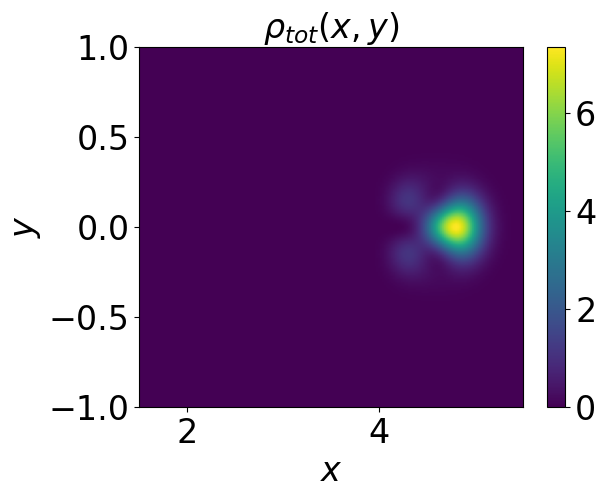

In [8]:
f   = torch.load("Ferretti.pt")
psi = f["psi_r_adi"] # (Nx, Ny, nstate) e.g. (512,512,2)
Qx, Qy = f["Q"]
dq     = f["dq"]

# density matrix
rho = psi.unsqueeze(-1) * psi.conj().unsqueeze(-2) # (Nx,Ny,2,2)
rho_tot = rho[..., 0, 0] + rho[..., 1, 1] 

plt.imshow(
    rho_tot.real.T, # transpose so x becomes horizontal
    extent=[Qx.min(), Qx.max(), Qy.min(), Qy.max()],
    origin="lower",
    aspect="auto",
)
plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.title(r"$\rho_{tot}(x,y)$")
plt.colorbar()

plt.xlim([1.5, 5.5])
plt.ylim([-1, 1])

# Total populations
dA  = dq.prod() # dx*dy per grid cell
P0  = rho[...,0,0].real.sum() * dA
P1  = rho[...,1,1].real.sum() * dA
print(f"P0={P0.item():.6f},  P1={P1.item():.6f},  total={P0+P1:.6f}")

### 3.2. Plotting the density matrix (in k-space) profiles of 2D system
<a name="3.2"></a>[Back to TOC](#TOC)

We can also plot density matrix in k-space.

**Discrete Fourier transform of r-space wavefunction**

For a given discrete 2D r-grid with lengths of $L_{x} = N_{x}\Delta x$ and $L_{y} = N_{y}\Delta y$,
\\[ \mathcal{R}= \{(x_{m}, y_{n}) | x_{m} = x_{min} + m dx, y_{n} = y_{min} + n dy, \: m \in \{0,1,\cdots N_{x} - 1 \},\: n \in \{0,1,\cdots N_{y} - 1 \} \}, \\]
the reciprocal space data, `f["psi_k_adi"]`, contains the unnormalized discrete Fourier transform results,
\\[ \underline{\Psi}(k_{x}, k_{y}) = [{\Psi}_{0}(k_{x},k_{y}) \quad {\Psi}_{1}(k_{x},k_{y})]^{T} \\]
over the reciprocal grid with length of $\Delta k_{x} = 2\pi/L_{x}$ and $\Delta k_{y} = 2\pi/L_{y}$,
\\[ \mathcal{K} = \{ (k_{x, p}, k_{y, q}) | k_{x, p} = p \Delta k_{x}, k_{y, q} = q \Delta k_{n},  \\]
\\[ p \in \mathcal{I}_{x} = \{0, 1, \cdots, \frac{N_{x}}{2} - 1, -\frac{N_{x}}{2}, \cdots -1 \}, q \in \mathcal{I}_{y} = \{0, 1, \cdots, \frac{N_{y}}{2} - 1, -\frac{N_{y}}{2}, \cdots -1 \} \} \\]
under the reciprocal relationship
\\[ \Delta z \Delta k_{z} = \frac{2\pi}{N_{z}} \quad \textrm{or} \quad \Delta k_{z} = \frac{2\pi}{L_{z}}  \quad (z=x,\; y). \\]

That is,
\\[ {\Psi}_{i}(k_{x,p}, k_{y,q}) = \sum_{m=0}^{N_{x}-1}\sum_{n=0}^{N_{y}-1} \psi_{i}(x_{m}, y_{n}) \exp \left[ -2\pi i \left(\frac{mp}{N_{x}} + \frac{nq}{N_{y}} \right) \right] \quad (i=0, 1). \\]


**Checking the identity from the Parseval theorem**

Then the Parseval theorem gaurantees
\\[ \sum_{m=0}^{N_{x}-1} \sum_{n=0}^{N_{x}-1} |\psi_{i}(x_{m}, y_{n})|^{2} = \frac{1}{N_{x}N_{y}} \sum_{p \in \mathcal{I}_{x}} \sum_{q \in \mathcal{I}_{y}} |{\Psi}_{i}(k_{x, p}, k_{y,q})|^{2}, \\]
which is confirmed in the following code block.

In [9]:
# Check the validity of the Parseval theorem
f   = torch.load("Ferretti.pt")
psi_r = f["psi_r_adi"]
psi_k = f["psi_k_adi"] 

rho_r = psi_r.unsqueeze(-1) * psi_r.conj().unsqueeze(-2)
rho_k = psi_k.unsqueeze(-1) * psi_k.conj().unsqueeze(-2)

Nx, Ny = psi.shape[:2]

print(rho_r[...,0,0].real.sum(), rho_k[...,0,0].real.sum()/Nx/Ny)
print(rho_r[...,1,1].real.sum(), rho_k[...,1,1].real.sum()/Nx/Ny)

tensor(5551.8350) tensor(5551.8350)
tensor(976.1190) tensor(976.1191)


**Normalization of the k-space density matrix**

The k-space vectorized wavefunction from the continuous FT, $\underline{\tilde{\psi}}(k_{x}, k_{y}) = [\tilde{\psi}_{0}(k_{x},k_{y}) \quad \tilde{\psi}_{1}(k_{x},k_{y})]^{T}$, should satisfy the norm conservation. Thus,

\\[ \sum_{p \in \mathcal{I}_{x}}\sum_{q \in \mathcal{I}_{y}} \mathrm{Tr} \underline{\underline{\tilde{\rho}}}(k_{x, p},k_{y, q}) \Delta k_{x} \Delta k_{y}  \approx \sum_{m=0}^{N_{x} - 1} \sum_{n=0}^{N_{y} - 1} \mathrm{Tr} \underline{\underline{\rho}}(x_{m},y_{n}) \Delta x \Delta y = 1, \\]
where $\underline{\underline{\tilde{\rho}}}$ is the k-space density matrix defined as

\\[ \underline{\underline{\tilde{\rho}}}(k_{x},k_{y}) = \underline{\tilde{\psi}}(k_{x},k_{y}) \underline{\tilde{\psi}}^{+}(k_{x},k_{y}) = \begin{bmatrix} \tilde{\psi}_{0}(k_{x},k_{y})\tilde{\psi}_{0}^{\ast}(k_{x},k_{y}) & \tilde{\psi}_{0}(k_{x},k_{y})\tilde{\psi}_{1}^{\ast}(k_{x},k_{y}) \\ \tilde\psi_{1}(k_{x},k_{y})\tilde{\psi}_{0}^{\ast}(k_{x},k_{y}) & \tilde\psi_{1}(k_{x},k_{y})\tilde\psi_{1}^{\ast}(k_{x},k_{y}) \end{bmatrix}. \\]

Utilizing the normalization conditions and relationship between $\underline{\psi}$ and the unnormalized $\underline{\Psi}$ yields

\\[ \sum_{p \in \mathcal{I}_{x}}\sum_{q \in \mathcal{I}_{y}} \mathrm{Tr} \underline{\tilde{\psi}}(k_{x},k_{y}) \underline{\tilde{\psi}}^{+}(k_{x},k_{y}) \Delta k_{x} \Delta k_{y}  \approx \sum_{p \in \mathcal{I}_{x}} \sum_{q \in \mathcal{I}_{y}} \mathrm{Tr} \underline{\Psi}(k_{x},k_{y}) \underline{\Psi}^{+}(k_{x},k_{y}) \frac{\Delta x \Delta y}{N_{x}N_{y}}, \\]

Thus, the normalized k-space density matrix $\tilde{\underline{\underline{\rho}}}$ is computed by 
\\[ \tilde{\underline{\underline{\rho}}} := \frac{\Delta x \Delta y}{\Delta k_{x} \Delta k_{y} N_{x}N_{y}} \underline{\Psi} \; \underline{\Psi}^{+}.\\]

**Shift of the k-space grid**

One last point to consider is the arrangement of the k-space grid. By default, the $k=0$ point is placed at the left edge of the array, so the density matrix in k-space without shifting appears in the corner of the plot. To obtain a physically natural k-axis, we need to shift the grid so that $k=0$ is positioned at the center. Utilizing the `torch.fft.fftshift` method, we can obtain the following centralized k-space grid.

\\[ \left[ 0, 1, \cdots, \frac{N_{z}}{2} - 1, -\frac{N_{z}}{2}, \cdots -1 \right] \mapsto \left[ -\frac{N_{z}-1}{2}, \cdots, 0, \cdots, \frac{N_{z}-1}{2} \right] \qquad (z=x,\; y) \\]

P0=0.850458,  P1=0.149527,  total=0.999985


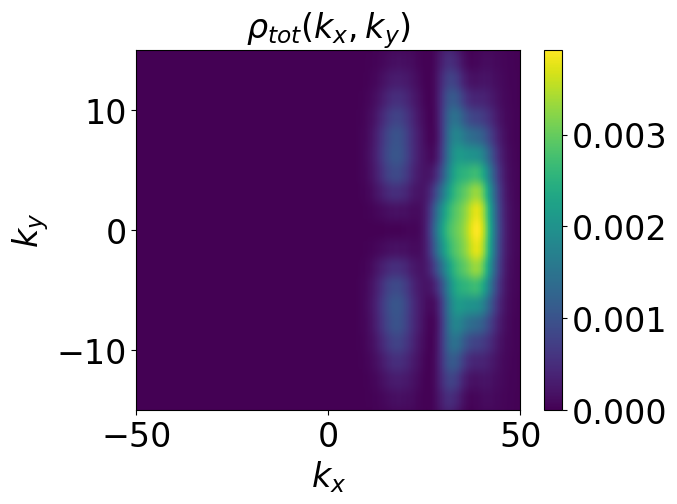

In [10]:
f   = torch.load("Ferretti.pt")
psi = f["psi_k_adi"]  # (Nx, Ny, nstate) e.g. (512,512,2)
Kx, Ky = f["K"]
dq     = f["dq"]
dk     = f["dk"]

rho = psi.unsqueeze(-1) * psi.conj().unsqueeze(-2) # (Nx,Ny,2,2)

# Shift the kx, ky axes
rho  = torch.fft.fftshift(rho,  dim=(0,1))
Kx   = torch.fft.fftshift(Kx)
Ky   = torch.fft.fftshift(Ky)

# Here, we normalize the psi
Nx, Ny = psi.shape[:2]
rho *= dq.prod()/Nx/Ny / dk.prod()

rho_tot = rho[...,0,0].real + rho[...,1,1].real

plt.imshow(
    rho_tot.real.T, # transpose so x becomes horizontal
    extent=[Kx.min(), Kx.max(), Ky.min(), Ky.max()],
    origin="lower",
    aspect="auto",
)
plt.xlabel(r"$k_{x}$")
plt.ylabel(r"$k_{y}$")
plt.title(r"$\rho_{tot}(k_{x},k_{y})$")
plt.colorbar()

plt.xlim([-50, 50])
plt.ylim([-15, 15])

# Total populations
dA = dk.prod()
P0  = rho[...,0,0].real.sum() * dA
P1  = rho[...,1,1].real.sum() * dA
print(f"P0={P0.item():.6f},  P1={P1.item():.6f},  total={P0+P1:.6f}")

### 3.3. Plotting the state-resolved density matrix (in r-space) profiles of 2D system
<a name="3.3"></a>[Back to TOC](#TOC)

Finally, let's do the r-space profiles, but using the adiabatic wavefunctions

P0=0.850458,  P1=0.149527,  total=0.999985


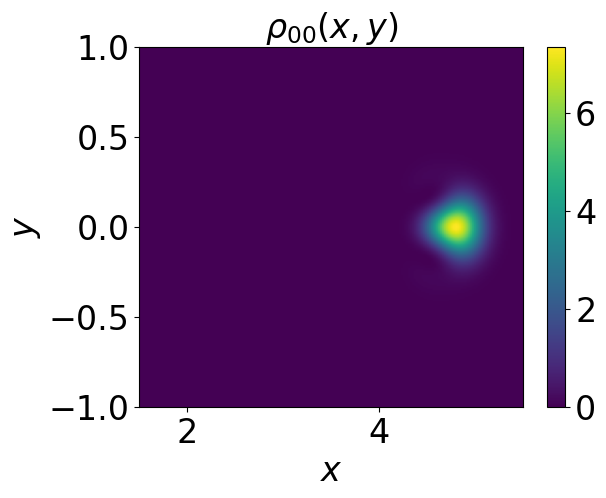

In [11]:
f   = torch.load("Ferretti.pt")
psi = f["psi_r_adi"]  # (Nx, Ny, nstate) e.g. (512,512,2)
Qx, Qy = f["Q"]
dq     = f["dq"]

# density matrix
rho = psi.unsqueeze(-1) * psi.conj().unsqueeze(-2)   # (Nx,Ny,2,2)

plt.imshow(
    rho[..., 0, 0].real.T, # transpose so x becomes horizontal
    extent=[Qx.min(), Qx.max(), Qy.min(), Qy.max()],
    origin="lower",
    aspect="auto",
)
plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.title(r"$\rho_{00}(x,y)$")
plt.colorbar()

plt.xlim([1.5, 5.5])
plt.ylim([-1, 1])

# Total populations
dA  = dq.prod() # dx·dy per grid cell
P0  = rho[...,0,0].real.sum() * dA
P1  = rho[...,1,1].real.sum() * dA
print(f"P0={P0.item():.6f},  P1={P1.item():.6f},  total={P0+P1:.6f}")

P0=0.850458,  P1=0.149527,  total=0.999985


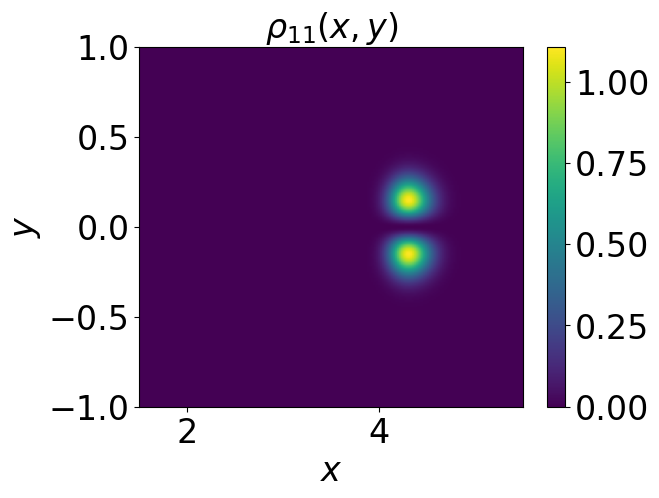

In [12]:
f   = torch.load("Ferretti.pt")
psi = f["psi_r_adi"] # (Nx, Ny, nstate)   e.g. (512,512,2)
Qx, Qy = f["Q"]
dq     = f["dq"]
grid   = f["grid_size"]

# density matrix
rho = psi.unsqueeze(-1) * psi.conj().unsqueeze(-2)   # (Nx,Ny,2,2)

plt.imshow(
    rho[..., 1, 1].real.T, # transpose so x becomes horizontal
    extent=[Qx.min(), Qx.max(), Qy.min(), Qy.max()],
    origin="lower",
    aspect="auto",
)
plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.title(r"$\rho_{11}(x,y)$")
plt.colorbar()

plt.xlim([1.5, 5.5])
plt.ylim([-1, 1])

# Total populations
dA  = dq.prod() # dx·dy per grid cell
P0  = rho[...,0,0].real.sum() * dA
P1  = rho[...,1,1].real.sum() * dA
print(f"P0={P0.item():.6f},  P1={P1.item():.6f},  total={P0+P1:.6f}")

### 3.4. Generating animation for the density matrix (in r-space) profiles of 2D system
<a name="3.4"></a>[Back to TOC](#TOC)

To monitor the electronic density propagation, let's generate movies for the density matrix over time. One is for the full density, and the other is showing the state-resolved one, with each adiabatic density in different colors (blue: ground & red: excited).

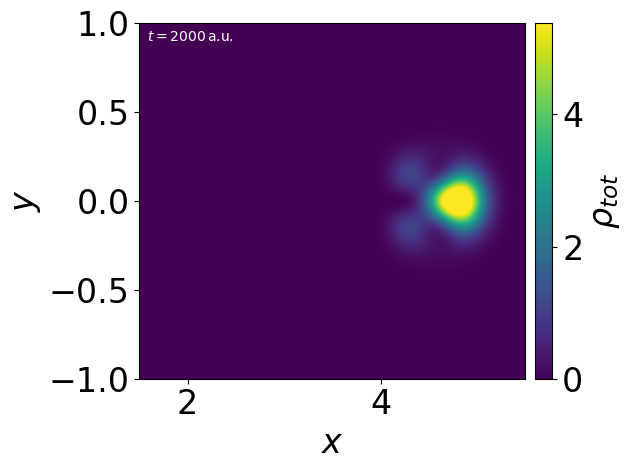

In [13]:
f        = torch.load("Ferretti.pt")
psi_all  = solver.psi_r_adi_all  # (Nt, Nx, Ny, 2)
Qx, Qy   = f["Q"]
Nt, Nx, Ny, _ = psi_all.shape
dt_frame = 50 # a.u. per stored frame

# setting from initial density
rho0 = (psi_all[0].unsqueeze(-1) * psi_all[0].conj().unsqueeze(-2)).real
rho0 = rho0[..., 0, 0] + rho0[..., 1, 1]

vmax = rho0.max().item()

fig, ax = plt.subplots()

ax.set_xlim([1.5, 5.5])
ax.set_ylim([-1, 1])

im = ax.imshow(rho0.T,
               extent=[Qx.min(), Qx.max(), Qy.min(), Qy.max()],
               origin="lower", aspect="auto", vmin=0, vmax=vmax)
cb = fig.colorbar(im, ax=ax, pad=0.02, label=r"$\rho_{tot}$")
ax.set_xlabel(r"$x$"); ax.set_ylabel(r"$y$")
fig.tight_layout()

time_txt = ax.text(0.02, 0.95, "", transform=ax.transAxes, color="w")

def update(frame):
    rho_tot = (psi_all[frame].unsqueeze(-1) * psi_all[frame].conj().unsqueeze(-2)).real
    rho_tot = rho_tot[..., 0, 0] + rho_tot[..., 1, 1]
    im.set_data(rho_tot.T)
    time_txt.set_text(rf"$t={frame*dt_frame}\,$a.u.")
    return im, time_txt

ani = animation.FuncAnimation(fig, update, frames=Nt, blit=True)

ani.save("ferretti_density.gif", writer="pillow")

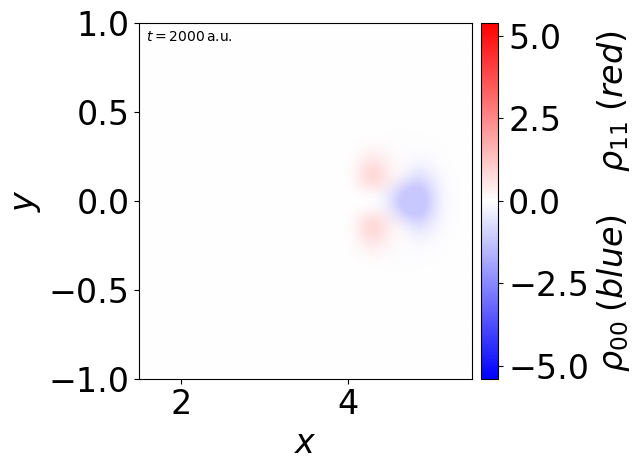

In [14]:
f        = torch.load("Ferretti.pt")
psi_all  = solver.psi_r_adi_all # (Nt, Nx, Ny, 2)
Qx, Qy   = f["Q"]
Nt, Nx, Ny, _ = psi_all.shape
dt_frame = 50 # a.u. per stored frame

rho = (psi_all[0].unsqueeze(-1) * psi_all[0].conj().unsqueeze(-2)).real
rho_g0, rho_e0 = rho[..., 0, 0].numpy(), rho[..., 1, 1].numpy()
vabs = max(rho_g0.max(), rho_e0.max()) # global max
norm = TwoSlopeNorm(vcenter=0.0, vmin=-vabs, vmax=vabs)

fig, ax = plt.subplots()
ax.set_xlim([1.5, 5.5]); ax.set_ylim([-1, 1])

im_g = ax.imshow((-rho_g0).T,
                 extent=[Qx.min(), Qx.max(), Qy.min(), Qy.max()],
                 origin="lower", aspect="auto",
                 cmap="bwr", norm=norm, alpha=0.7, zorder=1)

im_e = ax.imshow(rho_e0.T,
                 extent=[Qx.min(), Qx.max(), Qy.min(), Qy.max()],
                 origin="lower", aspect="auto",
                 cmap="bwr", norm=norm, alpha=0.7, zorder=2)

sm = plt.cm.ScalarMappable(cmap="bwr", norm=norm); sm.set_array([])
cb = fig.colorbar(sm, ax=ax, pad=0.02,
                  label=r"$\rho_{00}\;(blue)\quad\; \rho_{11}\;(red)$")

ax.set_xlabel(r"$x$"); ax.set_ylabel(r"$y$")
time_txt = ax.text(0.02, 0.95, "", transform=ax.transAxes, color="k")
fig.tight_layout()

def update(frame):
    rho = (psi_all[frame].unsqueeze(-1) * psi_all[frame].conj().unsqueeze(-2)).real
    rho_g, rho_e = rho[..., 0, 0].numpy(), rho[..., 1, 1].numpy()
    im_g.set_data((-rho_g).T)
    im_e.set_data((rho_e).T)
    time_txt.set_text(rf"$t={frame*dt_frame}\,$a.u.")
    return im_g, im_e, time_txt

ani = animation.FuncAnimation(fig, update, frames=Nt, blit=True)

ani.save("ferretti_density_statewise.gif", writer="pillow")

### 3.5. Generating animation for the density matrix (in k-space) profiles of 2D system
<a name="3.5"></a>[Back to TOC](#TOC)

As we generated movies on (state-resolved) density matrix profiles in r-space, we make movies in k-space.

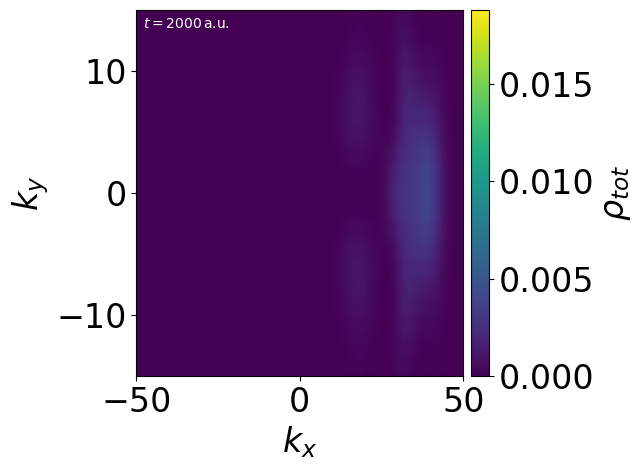

In [15]:
f        = torch.load("Ferretti.pt")
psi_all  = solver.psi_k_adi_all                      # (Nt, Nx, Ny, 2)
Kx, Ky = f["K"]                   # two 1‑D grids, each length Nx or Ny
dq     = f["dq"]                  # tensor([dx, dy])
dk     = f["dk"]                  # tensor([dkx, dky])
dt_frame = 50      

# setting from initial density
rho0 = (psi_all[0].unsqueeze(-1) * psi_all[0].conj().unsqueeze(-2)).real   # (Nx,Ny,2,2)

# Shift
rho0  = torch.fft.fftshift(rho0,  dim=(0,1))
Kx   = torch.fft.fftshift(Kx)
Ky   = torch.fft.fftshift(Ky)

# Normalize
Nt, Nx, Ny = psi_all.shape[:3]
rho0 *= dq.prod()/Nx/Ny / dk.prod()

rho0 = rho0[..., 0, 0] + rho0[..., 1, 1]

vmax = rho0.max().item()

fig, ax = plt.subplots()
ax.set_xlim([-50, 50])
ax.set_ylim([-15, 15])

im = ax.imshow(rho0.T,
               extent=[Kx.min(), Kx.max(), Ky.min(), Ky.max()],
               origin="lower", aspect="auto", vmin=0, vmax=vmax)
cb = fig.colorbar(im, ax=ax, pad=0.02, label=r"$\rho_{tot}$")
ax.set_xlabel(r"$k_{x}$"); ax.set_ylabel(r"$k_{y}$")
fig.tight_layout()

time_txt = ax.text(0.02, 0.95, "", transform=ax.transAxes, color="w")

def update(frame):
    rho_tot = (psi_all[frame].unsqueeze(-1) * psi_all[frame].conj().unsqueeze(-2)).real
    rho_tot = torch.fft.fftshift(rho_tot,  dim=(0,1))
    
    rho_tot *= dq.prod()/Nx/Ny / dk.prod()
    
    rho_tot = rho_tot[..., 0, 0] + rho_tot[..., 1, 1]
    im.set_data(rho_tot.T)
    time_txt.set_text(rf"$t={frame*dt_frame}\,$a.u.")
    return im, time_txt

ani = animation.FuncAnimation(fig, update, frames=Nt, blit=True)

ani.save("ferretti_density_k.gif", writer="pillow")

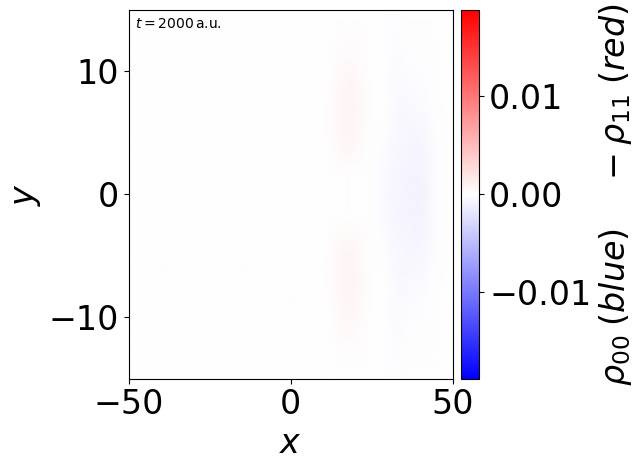

In [16]:
f        = torch.load("Ferretti.pt")
psi_all  = solver.psi_k_adi_all                      # (Nt, Nx, Ny, 2)
Kx, Ky   = f["K"]
dq     = f["dq"]                  # tensor([dx, dy])
dk     = f["dk"]                  # tensor([dkx, dky])
dt_frame = 50      

rho = (psi_all[0].unsqueeze(-1) * psi_all[0].conj().unsqueeze(-2)).real

# Shift
rho  = torch.fft.fftshift(rho,  dim=(0,1))
Kx   = torch.fft.fftshift(Kx)
Ky   = torch.fft.fftshift(Ky)

# Normalize
Nt, Nx, Ny = psi_all.shape[:3]
rho *= dq.prod()/Nx/Ny / dk.prod()

rho_g0, rho_e0 = rho[..., 0, 0].numpy(), rho[..., 1, 1].numpy()
vabs = max(rho_g0.max(), rho_e0.max()) # global max
norm = TwoSlopeNorm(vcenter=0.0, vmin=-vabs, vmax=vabs)

fig, ax = plt.subplots()
ax.set_xlim([-50, 50]); ax.set_ylim([-15, 15])

im_g = ax.imshow((-rho_g0).T,
                 extent=[Kx.min(), Kx.max(), Ky.min(), Ky.max()],
                 origin="lower", aspect="auto",
                 cmap="bwr", norm=norm, alpha=0.7, zorder=1)

im_e = ax.imshow(rho_e0.T,
                 extent=[Kx.min(), Kx.max(), Ky.min(), Ky.max()],
                 origin="lower", aspect="auto",
                 cmap="bwr", norm=norm, alpha=0.7, zorder=2)

# single shared colour‑bar
sm = plt.cm.ScalarMappable(cmap="bwr", norm=norm); sm.set_array([])
cb = fig.colorbar(sm, ax=ax, pad=0.02,
                  label=r"$\rho_{00}\;(blue)\quad\;-\rho_{11}\;(red)$")

ax.set_xlabel(r"$x$"); ax.set_ylabel(r"$y$")
time_txt = ax.text(0.02, 0.95, "", transform=ax.transAxes, color="k")
fig.tight_layout()

def update(frame):
    rho = (psi_all[frame].unsqueeze(-1) * psi_all[frame].conj().unsqueeze(-2)).real
    rho  = torch.fft.fftshift(rho,  dim=(0,1))
    rho  *= dq.prod()/Nx/Ny / dk.prod()

    rho_g, rho_e = rho[..., 0, 0].numpy(), rho[..., 1, 1].numpy()

    im_g.set_data((-rho_g).T)
    im_e.set_data((rho_e).T)
    time_txt.set_text(rf"$t={frame*dt_frame}\,$a.u.")
    return im_g, im_e, time_txt

ani = animation.FuncAnimation(fig, update, frames=Nt, blit=True)

ani.save("ferretti_density_k_statewise.gif", writer="pillow")

### 3.6. Plotting energy profiles: diabatic 
<a name="3.6"></a>[Back to TOC](#TOC)

First, let's plot the diabatic couplings and energies

y = 0.3326810300350189 Bohr


/home/alexvakimov/SOFTWARE/Conda/envs/libra/lib/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/alexvakimov/SOFTWARE/Conda/envs/libra/lib/python3.10/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


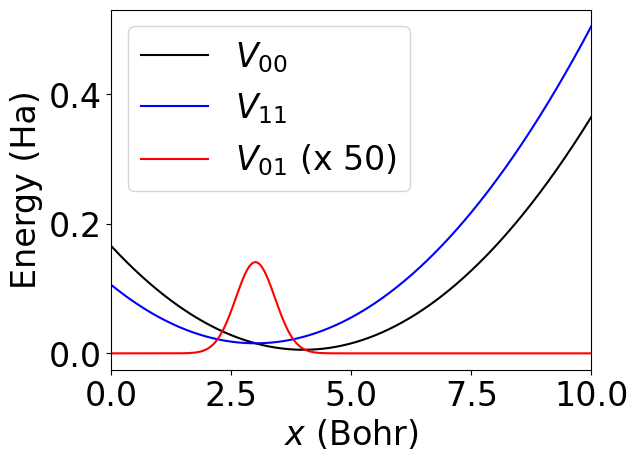

In [17]:
f = torch.load("Ferretti.pt")
Qx, Qy = f["Q"]

y_fix_ind = 298
print(F"y = {solver.Q[1, 0, y_fix_ind]} Bohr")
plt.plot(solver.Q[0, :, y_fix_ind], f["V"][:, y_fix_ind, 0, 0], color="black", label = "$V_{00}$")
plt.plot(solver.Q[0, :, y_fix_ind], f["V"][:, y_fix_ind, 1, 1], color="blue", label = "$V_{11}$")
plt.plot(solver.Q[0, :, y_fix_ind], f["V"][:, y_fix_ind, 0, 1]*50, color="red", label = "$V_{01}$ (x 50)")
plt.xlabel(r"$x$ (Bohr)")
plt.ylabel("Energy (Ha)")
plt.legend()
plt.margins(x=0)
plt.show()

### 3.7. Plotting energy profiles: adiabatic
<a name="3.7"></a>[Back to TOC](#TOC)

Now, let's do the adiabatic profiles.

y = 0.3326810300350189 Bohr


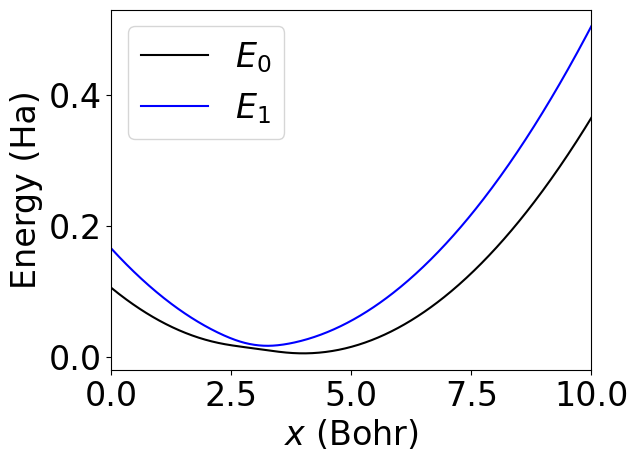

In [18]:
f = torch.load("Ferretti.pt")
Qx, Qy = f["Q"]

y_fix_ind = 298
print(F"y = {solver.Q[1, 0, y_fix_ind]} Bohr")
plt.plot(solver.Q[0, :, y_fix_ind], f["E"][:, y_fix_ind, 0], color="black", label = "$E_{0}$")
plt.plot(solver.Q[0, :, y_fix_ind], f["E"][:, y_fix_ind, 1], color="blue", label = "$E_{1}$")
plt.xlabel(r"$x$ (Bohr)")
plt.ylabel("Energy (Ha)")
plt.legend()
plt.margins(x=0)
plt.show()

### 3.8. Kinetic, potential, and total energy as functions of time
<a name="3.8"></a>[Back to TOC](#TOC)

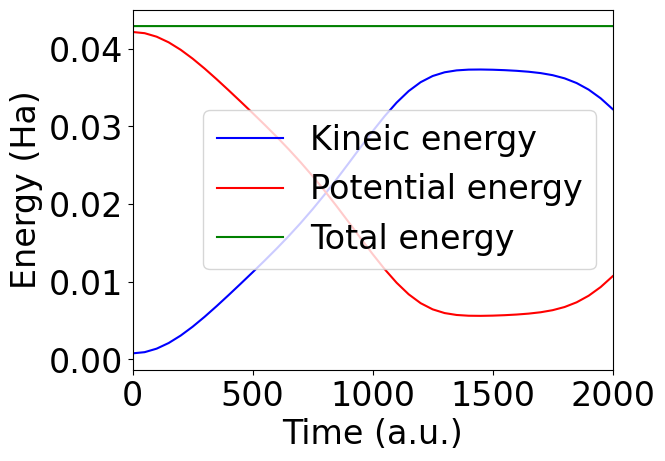

In [19]:
f = torch.load("Ferretti.pt")
t = f["time"].clone()
ekin = f["kinetic_energy"].clone()
epot = f["potential_energy"].clone()
etot = f["total_energy"].clone()

plt.plot(t, ekin, label="Kineic energy", color="blue")
plt.plot(t, epot, label="Potential energy", color="red")
plt.plot(t, etot, label="Total energy", color="green")
plt.xlabel("Time (a.u.)")
plt.ylabel("Energy (Ha)")
plt.legend()
plt.margins(x=0)
plt.show()

### 3.9. Adiabatic and diabatic populations as functions of time
<a name="3.9"></a>[Back to TOC](#TOC)

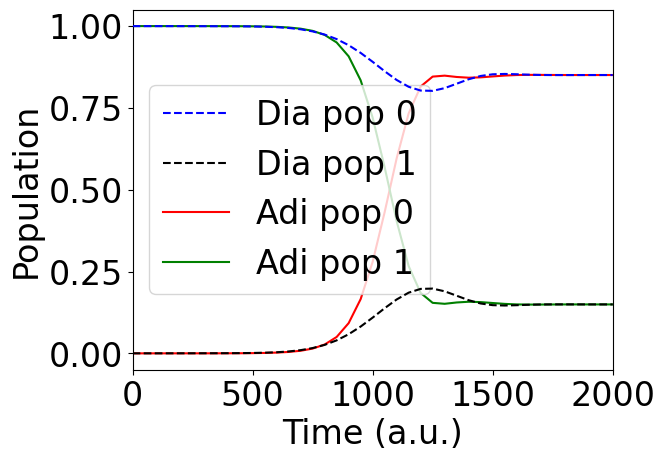

In [20]:
f = torch.load("Ferretti.pt")
t = f["time"].clone()
rho_dia = f["rho_dia_all"].clone()
rho_adi = f["rho_adi_all"].clone()

plt.plot(t[:], rho_dia[:,0,0], label="Dia pop 0", color="blue", ls="--", zorder=10)
plt.plot(t[:], rho_dia[:,1,1], label="Dia pop 1", color="black", ls="--", zorder=10)

plt.plot(t[:], rho_adi[:,0,0], label="Adi pop 0", color="red")
plt.plot(t[:], rho_adi[:,1,1], label="Adi pop 1", color="green")

plt.xlabel("Time (a.u.)")
plt.ylabel("Population")
plt.legend()
plt.margins(x=0)
plt.show()